# KNMI; getting weather data using a script

Weather and precipiation data can be requested directly from the KNMI website
by using the famous reques module. The URL is used and a payload that request
wil merge with the URL and sent to the KNMI data store.

"""https://www.knmi.nl/kennis-en-datacentrum/achtergrond/data-ophalen-vanuit-een-script

The result is an object that can be requested. It has an ok and a text which holds
the actual data as a single long string. The string is then parsed to get the data.

In our case, the string is written to a csv file and then parsed.
If the csv file witn the same name already exists, than that is parsed
instead of sending a request to KNMI.

The class Weather_stn can request daily values of the weather, of precipitation and
also hourly values of the weather.

When requesting weather data, one can use group parameters in the payload. These
make sure the correct related columns are returned.

Group parameters (vars)

* WIND = DDVEC:FG:FHX:FHX:FX wind
* TEMP = TG:TN:TX:T10N temperatuur
* SUNR = SQ:SP:Q Zonneschijnduur en globale straling
* PRCP = DR:RH:EV24 neerslag en potentiële verdamping
* PRES = PG:PGX:PGN druk op zeeniveau
* VICL = VVN:VVX:NG zicht en bewolking
* MSTR = UG:UX:UN luchtvochtigheid
* ALL  = alle variabelen

We will mostly use PRCP

Default is ALL.
"""

@TO 20240714

In [1]:
import os, sys

sys.path.insert(0, "/Users/Theo/Development/python/hydro_tools")

import numbers
import requests
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
from matplotlib.patches import Circle
from tools.KNMI.src.KNMI_data_from_URL import Weather_stn

print(f"cwd: {os.getcwd()}")
print(f"sys.executable: {sys.executable}")

month_names = 'jan feb mar apr mei juni juli aug sep okt nov dec'.split()

os.getcwd()
 /Users/Theo/Development/python/hydro_tools/tools/KNMI/notebooks
cwd: /Users/Theo/Development/python/hydro_tools/tools/KNMI/notebooks
sys.executable: /usr/local/bin/python3


## Name space for the project directories (can be expanded as needed)

In [2]:
class Dirs():
    def __init__(self):
        self.data = '/Users/Theo/Development/python/hydro_tools/tools/KNMI/data'
        # add other directories as neede

dirs = Dirs()
print(dirs.data)

/Users/Theo/Development/python/hydro_tools/tools/KNMI/data


# Getting daily and hourly weather and  precipitation datay

## Weather data for De Bilt (weather station 260)

In [3]:
# --- Data period:
startt = '19600101'
endt =   '20260701'
        
# %% --- Request data from KNMI or use file if it already exists.
        
# --- Weather data for De Bilt (Weather station 260)
DeBilt260 = Weather_stn(what='weather', start=startt, end=endt, stns='260', vars=['PRCP'], fmt='csv', folder=dirs.data)

# --- Return as pd.DataFrame
dB260 = DeBilt260.df

dB260.head()

# --- By postpending .df to the Weather_stn call one can immediately get the DataFrame

Outfile weer_260_PRCP_19600101_20260701.csv already exists in '/Users/Theo/Development/python/hydro_tools/tools/KNMI/data', request skipped.


,DR,RH,EV24
datetime,,,
1960-01-01,38.0,2.5,0.1
1960-01-02,13.0,0.6,0.2
1960-01-03,3.0,0.1,0.3
1960-01-04,45.0,0.9,0.1
1960-01-05,73.0,3.9,0.0


# Precipitation data for DeBilt (rain station 550)

In [4]:
# --- Precipitation data for De Bilt (Rain station 550)
#     postpend .df to get pd.DataFrame immediately
deBilt550 = Weather_stn(what='precipitation', start=startt, end=endt, stns='550', vars=['PRCP'], fmt='csv', folder=dirs.data).df

# --- Show DataFrame
deBilt550.head()

Outfile prec_550_19600101_20260701.csv already exists in '/Users/Theo/Development/python/hydro_tools/tools/KNMI/data', request skipped.


,RD,SX
datetime,,
1960-01-01 08:00:00,0.0,0
1960-01-02 08:00:00,2.5,0
1960-01-03 08:00:00,0.7,0
1960-01-04 08:00:00,0.1,0
1960-01-05 08:00:00,1.4,0


## Hourly data for De Bilt

First the rain data

In [5]:
# --- Hourly weather data (here just rain)
dBiltUur = Weather_stn(what='hourly', start=20260101, end=20260501,
                       stns='260', vars=['PRCP'], fmt='csv', folder=dirs.data).df

dBiltUur.head()


Outfile uur_260_RH_20260101_20260501.csv already exists in '/Users/Theo/Development/python/hydro_tools/tools/KNMI/data', request skipped.


,RH
2026-01-01 01:00:00,0.0
2026-01-01 02:00:00,0.0
2026-01-01 03:00:00,0.0
2026-01-01 04:00:00,0.0
2026-01-01 05:00:00,0.0


In [6]:
# --- Hourly weather data (here just rain)
dBiltUur = Weather_stn(what='hourly', start=20260101, end=20260501, stns='260', vars=['P', 'RH', 'FH', 'DD', 'U'], fmt='csv', folder=dirs.data).df

dBiltUur.head()

Outfile uur_260_P_RH_FH_DD_U_20260101_20260501.csv already exists in '/Users/Theo/Development/python/hydro_tools/tools/KNMI/data', request skipped.


,P,RH,FH,DD,U
2026-01-01 01:00:00,10136.0,0.0,40.0,250.0,78.0
2026-01-01 02:00:00,10127.0,0.0,50.0,240.0,76.0
2026-01-01 03:00:00,10112.0,0.0,50.0,240.0,75.0
2026-01-01 04:00:00,10097.0,0.0,50.0,240.0,76.0
2026-01-01 05:00:00,10081.0,0.0,60.0,240.0,74.0


# Show the precipitation stations (anno 2021)

The file with the Neerslagstations was downloaded from KNMI website in 2021.
Such files are updated when neerslagstations change.

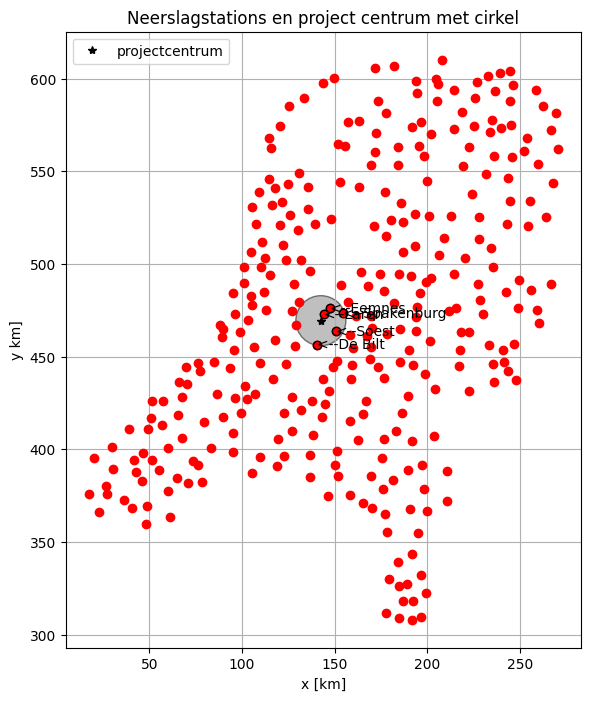

In [7]:
# %% --- Show neerslagstations KNMI anno 2021

# --- Let's define a project around a point
# --- Rondeellaan Hilversum    
xC, yC = 142.530, 469.420 # Centrum cirkel Rondeellaan Hilversum

# Get the closest KNMI precipitation stations closest to Rondeellaan Hilversum

# --- Meta data of the precipitation stations downloaded from KNMI
knmi_nsl_stns_csv = 'KNMI_neerslagstations_mei2021_1d.csv'
if not os.path.isfile(os.path.join(dirs.data, knmi_nsl_stns_csv)):
    raise FileNotFoundError(f"Can't find <{knmi_nsl_stns_csv}>")

# --- Read the file
nsl_stns = pd.read_csv(os.path.join(dirs.data, knmi_nsl_stns_csv))

# --- Add distance R to center of Rondeellaan Hilversum to the DataFrame of the prec. stations
dx, dy = nsl_stns['STN_POS_X'] - xC , nsl_stns['STN_POS_Y'] - yC
nsl_stns['R'] = np.round(np.sqrt(dx ** 2 + dy ** 2), decimals=1)

fig, ax = plt.subplots(figsize=(10, 8))
ax.set(title='Neerslagstations en project centrum met cirkel', xlabel='x [km]', ylabel='y km]')

# --- The stations
ax.plot(nsl_stns['STN_POS_X'], nsl_stns['STN_POS_Y'], 'ro')

# --- Get the 5 nearest stations
idx_nearest = nsl_stns['R'].sort_values().index[:5]
stns_nearest = nsl_stns.loc[idx_nearest]

# --- The 5 nearest sations
ax.plot(stns_nearest['STN_POS_X'], stns_nearest['STN_POS_Y'], 'ro', mec='k', mfc='none' )
ax.plot(xC, yC, 'k*', label='projectcentrum')

for idx in idx_nearest:
    stn = stns_nearest.loc[idx]
    ax.text(stn['STN_POS_X'], stn['STN_POS_Y'], "<--" + stn['LOCATIE'],
            ha='left', va='center')

# --- Circle / disk around project center
ci = Circle((xC, yC), radius=13.5, ec='k', fc='gray', alpha=0.5)
ax.add_patch(ci)

ax.grid()
ax.set_aspect(1.0)
ax.legend()
plt.show()

## Get and show RH and EV24 for De Bilt weerstation (260)

Outfile weer_260_PRCP_19600101_20260701.csv already exists in '/Users/Theo/Development/python/hydro_tools/tools/KNMI/data', request skipped.


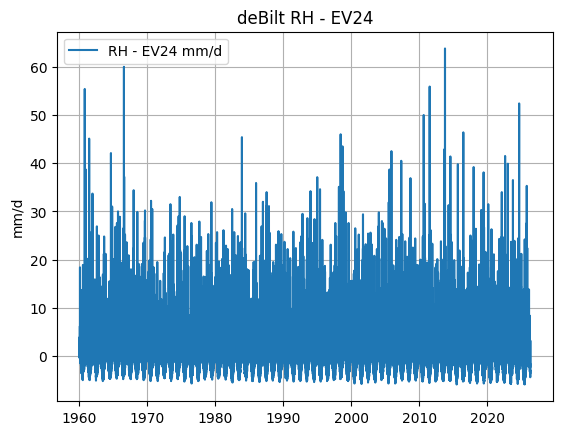

In [8]:
# %% --- Get the RH (prec) and EV24 (Makkink evapotransp) for De Bilt as a DataFrame
dB260 = Weather_stn(what='weather', start=startt, end=endt,
                        stns='260', vars=['PRCP'], fmt='csv', folder=dirs.data).df

fig, ax = plt.subplots()
ax.set_title('deBilt RH - EV24')
ax.set_ylabel('mm/d')

ax.plot(dB260.index, dB260['RH'] - dB260['EV24'], label='RH - EV24 mm/d')

ax.grid()
ax.legend()

# Get the precipitation data for the nearest 5 rain around given project center

But we don't do anything with it now.

In [9]:
# --- Get the precipitation data for the nearest 5 neerslagstations once again
for idx in stns_nearest.index:
    stn_meta = stns_nearest.loc[idx]

    # --- Request the data and save it
    knmi = Weather_stn(what='precipitation',
                        start=startt,
                        end=endt,
                        stns=stn_meta['STN'], # station number
                        folder=dirs.data)        

Outfile prec_593_19600101_20260701.csv already exists in '/Users/Theo/Development/python/hydro_tools/tools/KNMI/data', request skipped.
Outfile prec_596_19600101_20260701.csv already exists in '/Users/Theo/Development/python/hydro_tools/tools/KNMI/data', request skipped.
Outfile prec_595_19600101_20260701.csv already exists in '/Users/Theo/Development/python/hydro_tools/tools/KNMI/data', request skipped.
Outfile prec_576_19600101_20260701.csv already exists in '/Users/Theo/Development/python/hydro_tools/tools/KNMI/data', request skipped.
Outfile prec_550_19600101_20260701.csv already exists in '/Users/Theo/Development/python/hydro_tools/tools/KNMI/data', request skipped.


## Correlate the precipitation of nearby regenstations include weerstation De Bilt

Include the weather station DeBilt (260) and compute the correlation of their joint indices.

In [10]:
# ---The neerslagstations waarvan de RD date worden gecorreleerd
stnNms = ["Laren593", "Eemnes596", "Soest595", "Spakenburg576", "De Bilt550"]

# --- Get their station numbers
stns = [int(k[-3:]) for k in stnNms]

# --- Dictionary with the data
rdf = {}
for stn in stns:
    rdf[stn]=Weather_stn(what='precipitation',
                            start=startt, end=endt, stns=stn, vars=['PRCP'], fmt='csv', folder=dirs.data).df

# --- Tackle weerstation De Bilt separately
deBilt260 = 260
rdf[deBilt260]=Weather_stn(what='weather',
            start=startt, end=endt, stns=deBilt260, vars=['PRCP'], fmt='csv', folder=dirs.data).df

# --- Tackle that weerstation has RH and neerslagstations have RD
rdf[deBilt260].loc[:, 'RD'] = rdf[deBilt260].loc[:, 'RH']

# --- Shift index 1D and 8 hours to make the indexes of weerstation
#     compatible with neerslagstation
rdf[deBilt260].index += np.timedelta64(32, 'h') # Shift

# --- Print number of lines in each data set
print("STN lines")
for stn, df in rdf.items():
    print(f"{stn} {len(df)}") #  Pnp.unique(np.diff(df.index)))}")
    
#  --- Correlations between raindata
print("\nVerify rain station data series for gaps and missing values:\n")

# --- Combine all data sets in a single DataFrame
all_stns = pd.DataFrame()
for stn in stns:
    all_stns[stn] = rdf[stn]['RD']
    
# --- Add DeBilt
all_stns[260] = rdf[260]['RH']
    
# --- Keep only the matching indices
all_stns = all_stns.dropna(axis=1, how='any')
    
print(f"\nCorrelation between rain stations between {str(all_stns.index[0])[:10]} and {str(all_stns.index[-1])[:10]}:\n")

# --- Print the correlation coefficients.
print(np.round(all_stns.corr(), decimals=2))

Outfile prec_593_19600101_20260701.csv already exists in '/Users/Theo/Development/python/hydro_tools/tools/KNMI/data', request skipped.
Outfile prec_596_19600101_20260701.csv already exists in '/Users/Theo/Development/python/hydro_tools/tools/KNMI/data', request skipped.
Outfile prec_595_19600101_20260701.csv already exists in '/Users/Theo/Development/python/hydro_tools/tools/KNMI/data', request skipped.
Outfile prec_576_19600101_20260701.csv already exists in '/Users/Theo/Development/python/hydro_tools/tools/KNMI/data', request skipped.
Outfile prec_550_19600101_20260701.csv already exists in '/Users/Theo/Development/python/hydro_tools/tools/KNMI/data', request skipped.
Outfile weer_260_PRCP_19600101_20260701.csv already exists in '/Users/Theo/Development/python/hydro_tools/tools/KNMI/data', request skipped.
STN lines
593 14559
596 10722
595 11027
576 24176
550 24176
260 24232

Verify rain station data series for gaps and missing values:


Correlation between rain stations between 198

# Conclusions about the correlation between rain gauges

The correlation between De Bilt550 rain station and De Bil260 wheather station taken
directly is bad, which is likely because there is a 32 hour difference between the 24 hour period over which the rain in a rain station is recorded and a data of the value of a weather station.

The rain station value is always on 08:00h UTC of the day it is in the record.
The weather station is at 00:00 h UTC of the day it is in the record.

Most of the rain fell on the previous day (16 of the 24 hours).
So if we take the record day of the rain daily data and add 8 hours to is the record
datetime exactly equal the real recording.
If we want the have the datetime of the weerstation daily record to match the moment of
the recorded accumulated value we have to add 24 hours (midnight at the end of the record day). We we want to compare the weerstation daily data with that of the rain daily data

1) Add 8 h to the datetime of the rain station daily data
2) Add 32 h to the datetime fo the weather staion daily data.

This gives indeed the highest correlation between the rain station of De Bilt and the weather station record of De Bilt.

# Distance between the rain gauges

The distance between rain stations matters. So for Hilversum we should prefer
rain station Laren because it's nearest and then Dpakenburg. Together these
two (Laren and Spakenburg) constitute a full record since 1960.

For the EV24, we have to use De Bilt. It's datetime too can be increased by
32 hours to match the rain gauge recording. For EV24 the error is minor, because
evaporation until between midnight and 08:00 is minor compared to that between 08:00 and 24:00 on the previous day, for which the value was accumulated.


## Hilversum rain and evapotranspiration proxy

The hilvProx virtual rain gauge we will use for further analysis consists of

1) Spakenburg rain values
2) Laren rain values over writing the Spakenburg values for the shorter period over which Laren is available.
3) EV24 values of weather station De Bilt

Outfile weer_260_PRCP_19600101_20260701.csv already exists in '/Users/Theo/Development/python/hydro_tools/tools/KNMI/data', request skipped.
Outfile prec_576_19600101_20260701.csv already exists in '/Users/Theo/Development/python/hydro_tools/tools/KNMI/data', request skipped.
Outfile prec_593_19600101_20260701.csv already exists in '/Users/Theo/Development/python/hydro_tools/tools/KNMI/data', request skipped.


<Axes: xlabel='datetime'>

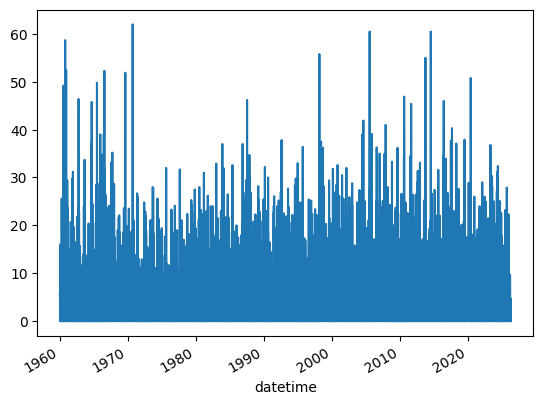

In [11]:
# %% --- Generate a proxy weather station for Hilversum

def generate_hilvProxy():
    """Return precipitation proxy as a pd.DataFrame.
            
    1) Spakenburg's RH
    2) Partly overwritten by Laren RH
    3) De Bilt (260) EV24
            
    Use global startt and endt in the top of this notebook
    """
    # --- The relevant KNMI stations
    stns = {"deBilt":260, "laren": 593, "spakenb": 576}
    
    # --- Start the proxy using De Bilt ('DR', 'RH', 'EV24')
    proxy = Weather_stn(what='weather',
                        start=startt, end=endt,
                        stns=stns['deBilt'], folder=dirs.data).df
    
    # --- Don't need rain duration
    proxy = proxy.drop(columns=['DR'])
    
    # --- Shift index over 1D + 8 hours so that EV24 is the accumulated
    #     value over 24 hours before the rain gauge recording.
    proxy.index += np.timedelta64(1, 'D') + np.timedelta64(8, 'h')
    
    # --- Get Spakeburg rain data
    spakenb = Weather_stn(what='precipitation',
                        start=startt, end=endt,
                        stns=stns['spakenb'], folder=dirs.data).df
    
    # --- Get Laren rain data
    laren = Weather_stn(what='precipitation',
                        start=startt, end=endt,
                        stns=stns['laren'], folder=dirs.data).df

    # --- First index of spakenb is not in DeBilt remove it
    spakenb = spakenb.iloc[1:, :]
    
    # --- Overwrite De Bilt 'RH' with Spakeburg 'RD'
    proxy.loc[spakenb.index, 'RH'] = spakenb['RD']
    
    # --- Overwrite De Bilt (now Spakenburg 'RD') with Laren 'RD'
    proxy.loc[laren.index,   'RH'] = laren['RD']
    
    # --- Drop lines with empty fields
    proxy = proxy.dropna()
    
    # --- Return hilvProxy
    return proxy

# --- Generate hilvProxy and save it
hilvProxy = generate_hilvProxy()
hilvProxy.to_csv(os.path.join(dirs.data, 'hilvProxy.csv'))
hilvProxy['RH'].plot()

## Rain surplus between october and may for every year since 1960

To demonstrate the extreme amount of precipitation surplus between Oct 2023 and end of spring 2024 we compute next the total rains surplus (RH - EV24) for De Bilt between Oct of the considered year until end of spring of the next year, and do that for every year since the beginning of the De Bilt wether data (1960-01-01).

Outfile weer_260_PRCP_19600101_20260701.csv already exists in '/Users/Theo/Development/python/hydro_tools/tools/KNMI/data', request skipped.


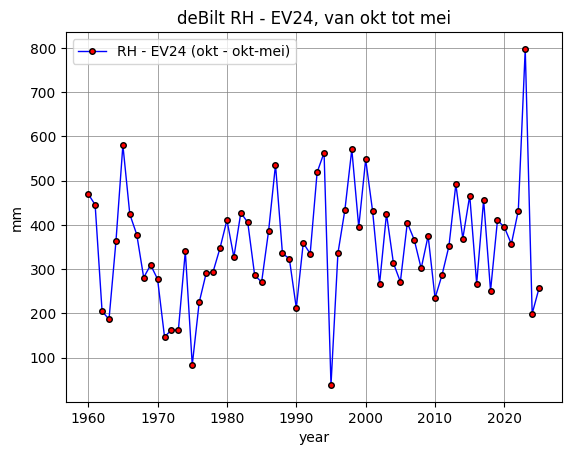

In [13]:
# --- Get De Bilt weather data
deBilt =Weather_stn(what='weather',
            start=startt, end=endt, stns=260, vars=['PRCP'], fmt='csv', folder=dirs.data).df

# --- Define the month in the current and next year
month1, month2, day = 10, 5, 1

# --- The two month names to use in plot label
mNm1, mNm2 = month_names[month1 -1], month_names[month2 -1]

# --- The years in the data
years = np.unique([dt.year for dt in hilvProxy.index])

# --- Define wettness 
wettness = []

# --- Compute it for every year
for year1, year2 in zip(years[:-1], years[1:]):
    start = np.datetime64(f"{year1:04d}-{month1:02d}-{day:02d}") + np.timedelta64(8, 'h')
    end   = np.datetime64(f"{year2:04d}-{month2:02d}-{day:02d}") + np.timedelta64(8, 'h')
    
    wettness.append((year1, 
            (hilvProxy.loc[start:end, 'RH'] - hilvProxy.loc[start:end, 'EV24']).sum())
        )

# --- Make array for plotting
wettness = np.array(wettness)

# --- Plot the wettness
fig, ax = plt.subplots()

ax.plot(wettness[:, 0], wettness[:, 1], 'o-',
        ms=4, mfc='r', mec='k', color='b', lw=1,
        label=f"RH - EV24 (okt - {mNm1}-{mNm2})")

ax.set_title(f"deBilt RH - EV24, van {mNm1} tot {mNm2}")
ax.set_xlabel('year')
ax.set_ylabel('mm')
ax.grid(visible=True, which='both', axis='both', color='gray', lw=0.5)
ax.legend()

plt.show()
